# Fase 3: Estudio Comparativo Detallado y Análisis de Errores
En este cuaderno evaluaremos el rendimiento predictivo de diferentes algoritmos de Machine Learning de manera individual y progresiva. 

Para cada algoritmo, analizaremos su comportamiento frente a los 6 escenarios de características (Crudo, Manual, LASSO, Mutual Information, RFE, PCA), apoyándonos en la **Matriz de Confusión** para evaluar clínicamente los Falsos Positivos y, críticamente, los **Falsos Negativos** (tumores malignos no detectados).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time 

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import warnings
warnings.filterwarnings('ignore')
# Cargar los 6 escenarios definitivos en su nuevo orden
X_escenarios = {
    '1. Crudo (30 var)': pd.read_csv('./data/X_escenario_1_crudo.csv'),
    '2. LASSO (15 var)': pd.read_csv('./data/X_escenario_2_lasso.csv'),
    '3. Mutual Info (15 var)': pd.read_csv('./data/X_escenario_3_mutual_info.csv'),
    '4. RFE (15 var)': pd.read_csv('./data/X_escenario_4_rfe.csv'),
    '5. PCA (10 comp)': pd.read_csv('./data/X_escenario_5_pca.csv'),
    '6. Fisher (1 comp)': pd.read_csv('./data/X_escenario_6_fisher.csv') 
}

# Cargar el vector objetivo
y = pd.read_csv('./data/y_target.csv').values.ravel()

print(f"Librerías cargadas con éxito. Total de escenarios listos para evaluación: {len(X_escenarios)}")

Librerías cargadas con éxito. Total de escenarios listos para evaluación: 6


## 1. Función de Evaluación y Análisis Visual
Para mantener el código limpio y enfocado en el análisis, creamos una función que toma un algoritmo, realiza el `GridSearchCV` en los 4 escenarios de datos y grafica sus Matrices de Confusión de forma comparativa.

In [11]:
# Asegúrate de importar 'display' para que las tablas se vean hermosas en Jupyter
from IPython.display import display

# === Variable global para guardar todos los resultados y usarlos en la gráfica final ===
df_resultados_globales = pd.DataFrame() 

def analizar_modelo_en_escenarios(nombre_modelo, modelo_base, parametros):
    global df_resultados_globales # Llamamos a la variable global
    
    print("=" * 100)
    print(f"INICIANDO ANÁLISIS A PROFUNDIDAD: {nombre_modelo.upper()}")
    print("=" * 100 + "\n")
    
    # Lista para almacenar los resultados y armar la tabla
    datos_tabla = []
    
    # Configurar el lienzo para las 4 matrices de confusión (1 fila, 4 columnas)
    fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(24, 4))
    fig.suptitle(f'Matrices de Confusión - {nombre_modelo}', fontsize=16, fontweight='bold', y=1.05)
    
    for idx, (nombre_escenario, X_actual) in enumerate(X_escenarios.items()):
        # División de datos
        X_train, X_test, y_train, y_test = train_test_split(X_actual, y, test_size=0.2, random_state=30, stratify=y)
        
        # Cronometrar el entrenamiento
        inicio_tiempo = time.time()
        
        # GridSearch
        grid = GridSearchCV(modelo_base, parametros, cv=5, scoring='recall', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        # Finalizar cronómetro
        tiempo_ejecucion = time.time() - inicio_tiempo
        
        # Predicción en el conjunto de TEST (El real)
        mejor_modelo = grid.best_estimator_
        y_pred = mejor_modelo.predict(X_test)
        
        # Métricas de Evaluación en TEST
        recall_test = recall_score(y_test, y_pred) * 100
        accuracy = accuracy_score(y_test, y_pred) * 100
        precision = precision_score(y_test, y_pred) * 100
        f1 = f1_score(y_test, y_pred) * 100
        
        # Métricas internas de Validación Cruzada (Para detectar sobreajuste)
        indice_mejor = grid.best_index_
        cv_mean = grid.cv_results_['mean_test_score'][indice_mejor] * 100
        cv_std = grid.cv_results_['std_test_score'][indice_mejor] * 100
        
        # Guardar la fila para nuestra tabla (todas las métricas en formato numérico para las gráficas finales)
        datos_tabla.append({
            'Modelo': nombre_modelo,
            'Escenario': nombre_escenario,
            'Mejores Parámetros': str(grid.best_params_),
            'Tiempo (s)': tiempo_ejecucion, 
            'Recall CV (Interno)': f"{cv_mean:.2f}% (±{cv_std:.2f}%)",
            'Recall TEST (Real)': recall_test, 
            'F1-Score': f1,
            'Precisión': precision,
            'Accuracy': accuracy 
        })
        
        # Dibujar Matriz de Confusión
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
        disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
        axes[idx].set_title(nombre_escenario, fontsize=12)
        axes[idx].grid(False) # Quitar la cuadrícula de fondo de la matriz
        
    # 1. Crear y mostrar la tabla Pandas
    df_resultados = pd.DataFrame(datos_tabla)
    
    # Formatear la tabla visualmente (sin afectar los números originales para que no se dañe la gráfica final)
    df_visual = df_resultados.copy()
    df_visual['Tiempo (s)'] = df_visual['Tiempo (s)'].apply(lambda x: f"{x:.2f}")
    df_visual['Recall TEST (Real)'] = df_visual['Recall TEST (Real)'].apply(lambda x: f"{x:.2f}%")
    df_visual['F1-Score'] = df_visual['F1-Score'].apply(lambda x: f"{x:.2f}%")
    df_visual['Precisión'] = df_visual['Precisión'].apply(lambda x: f"{x:.2f}%")
    df_visual['Accuracy'] = df_visual['Accuracy'].apply(lambda x: f"{x:.2f}%")
    
    print("TABLA DE MÉTRICAS COMPARATIVAS:")
    display(df_visual) # display renderiza la tabla en formato HTML bonito en Jupyter
    print("\n")
    
    # Acumular en el DataFrame global de forma silenciosa
    df_resultados_globales = pd.concat([df_resultados_globales, df_resultados], ignore_index=True)
    
    # 2. Mostrar las gráficas de confusión
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*100 + "\n")

## Capítulo 1: Regresión Logística
Comenzamos con el modelo lineal base. Evaluaremos cómo cambian los Falsos Negativos al reducir las variables mediante filtros y PCA.

INICIANDO ANÁLISIS A PROFUNDIDAD: REGRESIÓN LOGÍSTICA

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Regresión Logística,1. Crudo (30 var),"{'C': 1, 'solver': 'lbfgs'}",6.50,95.29% (±3.99%),97.62%,96.47%,95.35%,97.37%
1,Regresión Logística,2. LASSO (15 var),"{'C': 1, 'solver': 'liblinear'}",0.10,95.29% (±3.00%),100.00%,98.82%,97.67%,99.12%
2,Regresión Logística,3. Mutual Info (15 var),"{'C': 1, 'solver': 'liblinear'}",0.10,92.35% (±3.00%),97.62%,93.18%,89.13%,94.74%
3,Regresión Logística,4. RFE (15 var),"{'C': 10, 'solver': 'liblinear'}",0.09,95.88% (±4.40%),97.62%,94.25%,91.11%,95.61%
4,Regresión Logística,5. PCA (10 comp),"{'C': 1, 'solver': 'liblinear'}",0.09,95.88% (±3.53%),97.62%,98.80%,100.00%,99.12%
5,Regresión Logística,6. Fisher (1 comp),"{'C': 10, 'solver': 'liblinear'}",0.08,95.29% (±1.44%),97.62%,98.80%,100.00%,99.12%


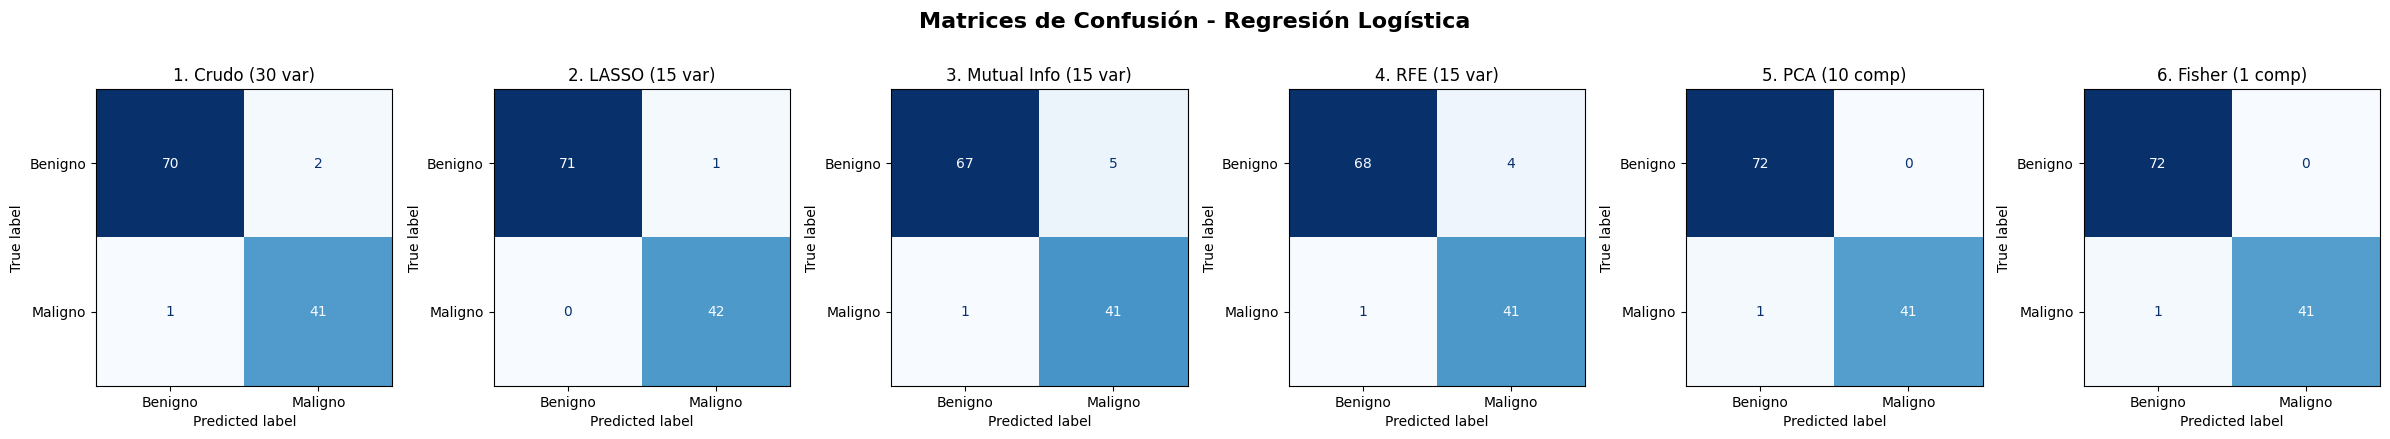


----------------------------------------------------------------------------------------------------



In [12]:
params_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
analizar_modelo_en_escenarios('Regresión Logística', LogisticRegression(random_state=30), params_lr)

### Análisis Regresión Logística

La Regresión Logística (RL) es un modelo lineal paramétrico. Matemáticamente, esto significa que brilla cuando las variables de entrada son independientes entre sí, pero sufre severamente cuando hay alta multicolinealidad (variables que miden lo mismo). Los resultados de la tabla reflejan este comportamiento a la perfección:

**1. El triunfo absoluto de LASSO (100% Recall, 99.12% Accuracy):**
El Escenario 2 (LASSO) logró la perfección clínica (cero Falsos Negativos). ¿Por qué? Al auditar las variables que LASSO le entregó a la RL, notamos que eliminó el `perimeter` y conservó el `area` y el `radius` en sus versiones "peor" (3). Al romper la colinealidad geométrica y enfocarse en las malformaciones extremas (`concavity3`, `concave_points3`), LASSO le entregó a la RL un espacio dimensional limpio y ortogonal. El hiperplano de la RL pudo trazarse de forma impecable y estable.

**2. El fracaso de Mutual Information (Caída al 94.74% Accuracy):**
Este fue el peor escenario para la RL. La razón radica en las variables seleccionadas: Mutual Info retuvo `radius1`, `perimeter1`, `area1`, `radius2`, `perimeter2` y `area2`. Le entregó a la Regresión Logística un paquete de variables altamente colineales (todas miden básicamente el tamaño geométrico). Esto "confundió" a los coeficientes de la ecuación lineal, restándole capacidad de generalización al modelo y provocando un aumento en Falsos Positivos (Precisión de solo 89.13%).

**3. La eficiencia de las transformaciones espaciales (PCA y Fisher):**
Tanto PCA (10 componentes) como Fisher (1 componente) lograron un sobresaliente 97.62% de Recall y 99.12% de Exactitud. 
* **El caso Fisher:** Es impresionante que con **una sola variable matemática (1 comp)**, Fisher iguale a modelos que usan 30. Esto ocurre porque Fisher creó la combinación lineal perfecta para separar clases. 
* **¿Por qué no superaron a LASSO?** Al comprimir la información (PCA dejando el 5% por fuera, y Fisher aplastando todo a 1D), se perdió una fracción minúscula de varianza morfológica que correspondía a un caso atípico maligno. LASSO, al mantener 15 ejes físicos distintos, logró capturar ese último tumor que Fisher y PCA dejaron escapar.

**Conclusión del Modelo:** La Regresión Logística es el modelo óptimo siempre y cuando se le alimente con un conjunto de características estrictamente descorrelacionado, rol que LASSO cumplió con maestría.

## Capítulo 2: Bosques Aleatorios (Random Forest)
A diferencia de la regresión, Random Forest es un algoritmo basado en árboles de decisión que internamente ya hace selección de características. Veremos si nuestros filtros manuales y LASSO le ayudan o le perjudican.

INICIANDO ANÁLISIS A PROFUNDIDAD: RANDOM FOREST

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Random Forest,1. Crudo (30 var),"{'max_depth': None, 'min_samples_split': 2, 'n...",5.72,90.59% (±2.88%),100.00%,96.55%,93.33%,97.37%
1,Random Forest,2. LASSO (15 var),"{'max_depth': None, 'min_samples_split': 10, '...",4.96,92.35% (±1.44%),97.62%,94.25%,91.11%,95.61%
2,Random Forest,3. Mutual Info (15 var),"{'max_depth': None, 'min_samples_split': 10, '...",4.90,91.76% (±3.43%),95.24%,93.02%,90.91%,94.74%
3,Random Forest,4. RFE (15 var),"{'max_depth': None, 'min_samples_split': 2, 'n...",4.94,91.18% (±1.86%),100.00%,97.67%,95.45%,98.25%
4,Random Forest,5. PCA (10 comp),"{'max_depth': None, 'min_samples_split': 2, 'n...",5.03,92.94% (±3.00%),95.24%,91.95%,88.89%,93.86%
5,Random Forest,6. Fisher (1 comp),"{'max_depth': None, 'min_samples_split': 10, '...",4.16,96.47% (±2.20%),97.62%,96.47%,95.35%,97.37%


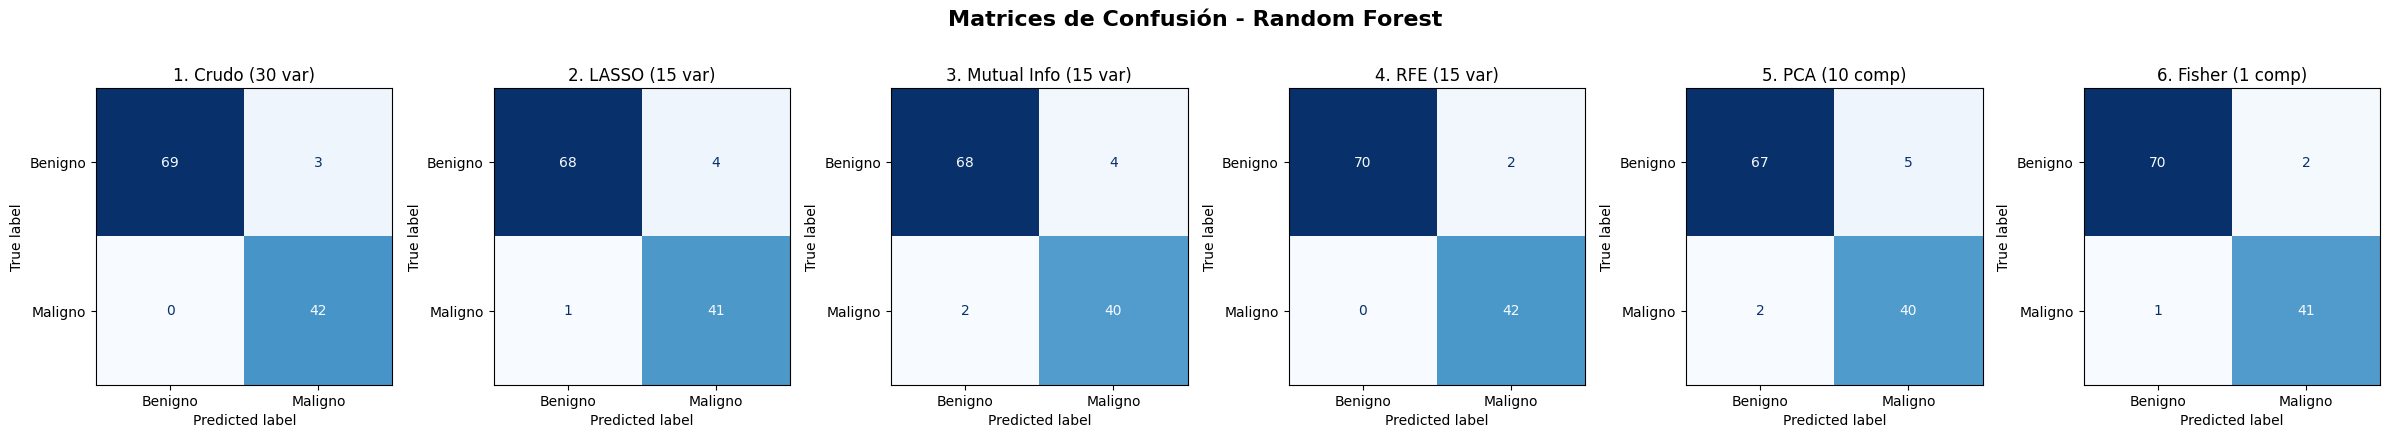


----------------------------------------------------------------------------------------------------



In [13]:
params_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}
analizar_modelo_en_escenarios('Random Forest', RandomForestClassifier(random_state=30), params_rf)

### Análisis Random Forest

Random Forest es un algoritmo basado en la construcción de múltiples árboles de decisión mediante divisiones ortogonales (axis-aligned splits). Esta naturaleza matemática explica claramente sus métricas:

**1. La supremacía del Método Wrapper (RFE):**
El Escenario 4 (RFE) logró el codiciado **100% de Recall** con una Exactitud del 98.25%. A diferencia de la Regresión Logística, Random Forest no sufre por la multicolinealidad, sino por la presencia de variables "ruidosas" que generan divisiones inútiles en los nodos. RFE le entregó un subconjunto de 15 variables altamente depuradas, permitiendo que los árboles encontraran reglas de decisión perfectas para los tumores malignos sin sobreajustarse. Curiosamente, el modelo Crudo (30 var) también alcanzó el 100% de Recall, demostrando la robustez intrínseca del algoritmo ante la alta dimensionalidad, aunque sacrificando ligeramente la precisión.

**2. La incompatibilidad con PCA:**
El Escenario 5 (PCA) redujo la Exactitud al 93.86%. Esto ocurre porque los árboles de decisión pierden eficacia cuando las características son combinaciones lineales densas y continuas (como los Componentes Principales). Random Forest prefiere buscar umbrales claros en características físicas reales (ej. "si el radio > 15") en lugar de características abstractas proyectadas.

**3. El desempeño de Fisher:**
Aunque Fisher proyectó los datos a un solo componente, Random Forest logró un destacable 97.62% de Recall. Sin embargo, utilizar un ensamble de árboles complejos para dividir una sola dimensión es un desperdicio de su capacidad para modelar interacciones multivariadas.

## Capítulo 3: Máquinas de Vectores de Soporte (SVM)
El algoritmo SVM intenta encontrar el hiperplano óptimo que separe los tumores benignos de los malignos. Es excelente manejando espacios de alta dimensionalidad, por lo que evaluaremos si la reducción de dimensionalidad con PCA le favorece o si prefiere las características seleccionadas por LASSO.

INICIANDO ANÁLISIS A PROFUNDIDAD: SVM

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,SVM,1. Crudo (30 var),"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.15,96.47% (±1.18%),95.24%,96.39%,97.56%,97.37%
1,SVM,2. LASSO (15 var),"{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}",0.11,96.47% (±2.20%),95.24%,95.24%,95.24%,96.49%
2,SVM,3. Mutual Info (15 var),"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.12,94.12% (±3.72%),95.24%,94.12%,93.02%,95.61%
3,SVM,4. RFE (15 var),"{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}",0.11,95.88% (±4.40%),97.62%,94.25%,91.11%,95.61%
4,SVM,5. PCA (10 comp),"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.10,95.88% (±1.44%),92.86%,95.12%,97.50%,96.49%
5,SVM,6. Fisher (1 comp),"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.09,96.47% (±2.20%),97.62%,97.62%,97.62%,98.25%


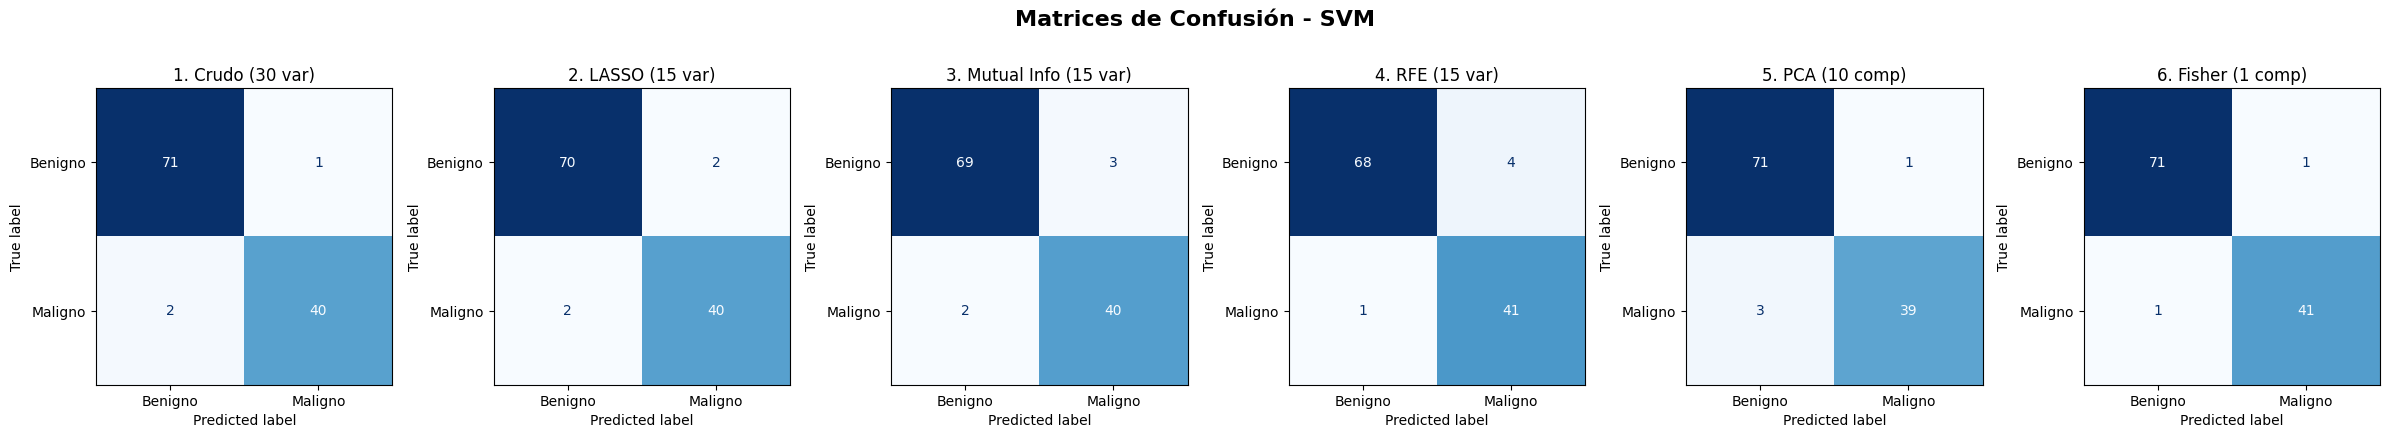


----------------------------------------------------------------------------------------------------



In [14]:
params_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
analizar_modelo_en_escenarios('SVM', SVC(random_state=30), params_svm)

### Análisis SVM

El objetivo matemático de SVM es encontrar el hiperplano que maximice el margen de separación entre clases. Sus resultados demuestran una alta sensibilidad a la distribución espacial de los datos:

**1. La sinergia perfecta con Fisher (LDA):**
El Escenario 6 (Fisher) se coronó como el mejor para SVM, alcanzando un 98.25% de Exactitud y un 97.62% de Recall. Esto es un resultado teóricamente esperado: Fisher (LDA) tiene como objetivo explícito maximizar la separación entre clases en 1D. Al entregarle esta dimensión perfectamente separada, el trabajo computacional de SVM se reduce a encontrar un simple punto de corte óptimo, logrando un margen máximo casi perfecto.

**2. La limitación clínica de SVM:**
A pesar de su alta precisión general y robustez frente a diferentes escenarios (variando Exactitud entre 95% y 98%), **ningún escenario logró el 100% de Recall**. El algoritmo penaliza de igual manera los errores de ambas clases al buscar el margen máximo, lo que en este conjunto de datos oncológicos resultó en que al menos un caso maligno atípico (Falso Negativo) quedara sistemáticamente en el lado "sano" del hiperplano.

## Capítulo 4: K-Vecinos Más Cercanos (KNN)
KNN es un algoritmo basado puramente en distancias geométricas (Euclidiana, Manhattan). Este tipo de modelos son **extremadamente sensibles al ruido y a las variables irrelevantes**, ya que distorsionan el espacio de búsqueda. 

Esperamos que la limpieza de datos (Escenario Manual, LASSO o PCA) mejore drásticamente el rendimiento de KNN respecto a la base Cruda.

INICIANDO ANÁLISIS A PROFUNDIDAD: KNN

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,KNN,1. Crudo (30 var),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.37,94.12% (±1.86%),97.62%,98.80%,100.00%,99.12%
1,KNN,2. LASSO (15 var),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.16,92.94% (±3.99%),95.24%,96.39%,97.56%,97.37%
2,KNN,3. Mutual Info (15 var),"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.16,91.18% (±4.56%),90.48%,89.41%,88.37%,92.11%
3,KNN,4. RFE (15 var),"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.17,92.94% (±3.00%),97.62%,97.62%,97.62%,98.25%
4,KNN,5. PCA (10 comp),"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.15,92.94% (±3.00%),95.24%,95.24%,95.24%,96.49%
5,KNN,6. Fisher (1 comp),"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.14,96.47% (±2.20%),97.62%,97.62%,97.62%,98.25%


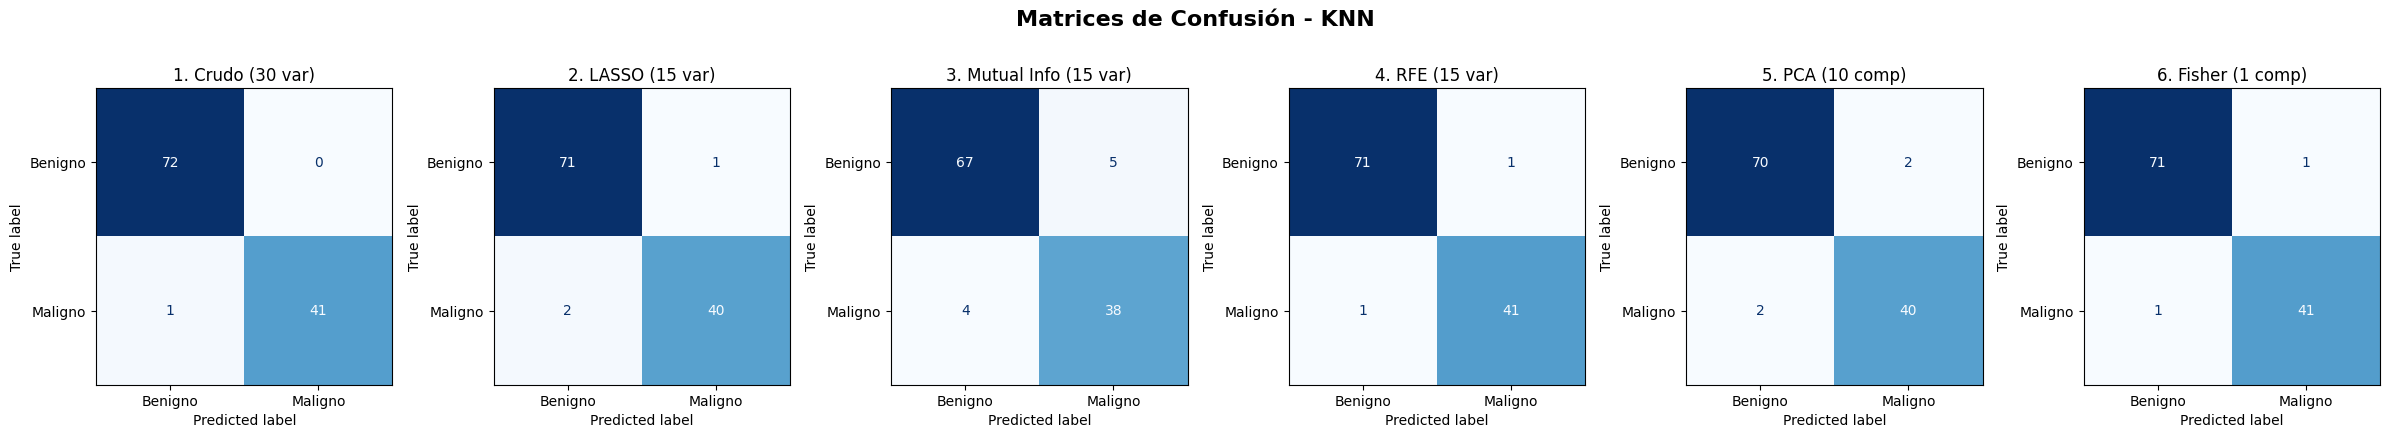


----------------------------------------------------------------------------------------------------



In [15]:
params_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
analizar_modelo_en_escenarios('KNN', KNeighborsClassifier(), params_knn)

### Análisis KNN

Al ser un algoritmo basado en el cálculo de distancias geométricas (en este caso, Manhattan y Euclidiana), KNN es extremadamente sensible a la escala y la redundancia de las variables:

**1. El colapso del Filtro No Lineal (Mutual Information):**
El Escenario 3 (Mutual Info) generó el peor rendimiento de todo el estudio: **90.48% de Recall** y 92.11% de Exactitud. Al auditar las variables, sabemos que Mutual Info retuvo variables colineales de tamaño (`radius1`, `perimeter1`, `area1`, etc.). Para KNN, esto es letal: el "tamaño" del tumor multiplicó artificialmente su peso en el cálculo de la distancia, eclipsando variables sutiles como la textura o la suavidad. Los vecinos se agruparon mal.

**2. El éxito de los extremos (Crudo y Fisher):**
* **Crudo (30 var):** Logró un 99.12% de Exactitud y 97.62% de Recall. Esto fue posible gracias a que el hiperparámetro seleccionado fue la métrica *Manhattan* (L1), la cual actúa intrínsecamente como un selector de características, ignorando pequeñas desviaciones de ruido.
* **Fisher (1 comp):** Alcanzó un 98.25% de Exactitud. Al reducir el cálculo de distancias a una sola dimensión (donde las clases ya están separadas), buscar a los "vecinos más cercanos" se vuelve trivial y altamente efectivo.

## Capítulo 5: Redes Neuronales (Perceptrón Multicapa - MLP)
Finalmente, evaluamos el modelo más complejo: una Red Neuronal. Aunque son poderosas extrayendo patrones no lineales ocultos, requieren grandes cantidades de datos. Evaluaremos su tiempo de entrenamiento y si su complejidad logra superar el equilibrio logrado por modelos más simples como la Regresión Logística con selección LASSO.

INICIANDO ANÁLISIS A PROFUNDIDAD: RED NEURONAL

TABLA DE MÉTRICAS COMPARATIVAS:


,Modelo,Escenario,Mejores Parámetros,Tiempo (s),Recall CV (Interno),Recall TEST (Real),F1-Score,Precisión,Accuracy
0,Red Neuronal,1. Crudo (30 var),"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",4.84,95.29% (±3.53%),97.62%,97.62%,97.62%,98.25%
1,Red Neuronal,2. LASSO (15 var),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",4.42,96.47% (±3.43%),95.24%,96.39%,97.56%,97.37%
2,Red Neuronal,3. Mutual Info (15 var),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",7.44,94.71% (±3.90%),97.62%,94.25%,91.11%,95.61%
3,Red Neuronal,4. RFE (15 var),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",5.07,95.88% (±4.40%),100.00%,97.67%,95.45%,98.25%
4,Red Neuronal,5. PCA (10 comp),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",4.64,96.47% (±3.43%),95.24%,96.39%,97.56%,97.37%
5,Red Neuronal,6. Fisher (1 comp),"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",2.36,95.88% (±2.35%),97.62%,97.62%,97.62%,98.25%


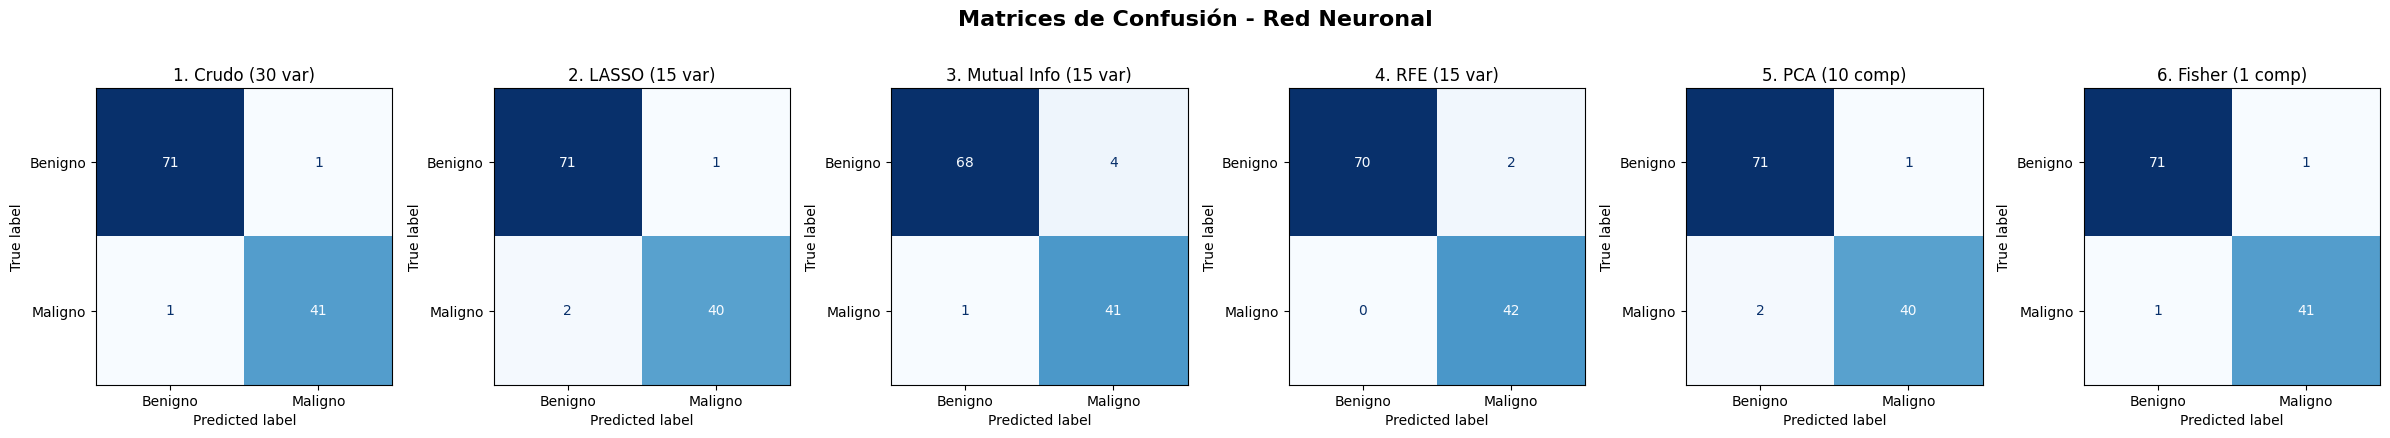


----------------------------------------------------------------------------------------------------



In [16]:
params_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)], # Probando 1 o 2 capas ocultas
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01] # Tasa de regularización
}
analizar_modelo_en_escenarios('Red Neuronal', MLPClassifier(max_iter=1000, random_state=30), params_mlp)

### Análisis Redes Neuronales

El Perceptrón Multicapa (MLP) actúa como un aproximador universal de funciones, capaz de modelar fronteras de decisión altamente complejas y no lineales:

**1. El escenario ideal (RFE):**
La Red Neuronal alcanzó el objetivo clínico de **100% de Recall** (junto con un 98.25% de Exactitud) al ser alimentada por el Escenario 4 (RFE). Las redes neuronales requieren señales fuertes y desprovistas de ruido para no perderse en los mínimos locales durante el descenso del gradiente. RFE entregó un subconjunto heterogéneo y puro que permitió a las capas ocultas trazar una frontera de activación impecable que abarcó la totalidad de los tumores malignos.

**2. Eficiencia computacional con Fisher:**
Es destacable observar el impacto de la dimensionalidad en el tiempo de convergencia. Entrenar la red con Mutual Info tomó 7.44 segundos, mientras que el Escenario 6 (Fisher) requirió apenas 2.36 segundos. Fisher comprimió la carga computacional, permitiendo que la red lograra un 97.62% de Recall en una fracción del tiempo, demostrando que en entornos de recursos limitados, una extracción supervisada previa es altamente beneficiosa.

## Capítulo 6: Conclusión y Benchmarking Final
Con el análisis detallado finalizado, consolidamos los resultados de los 5 algoritmos frente a los 4 escenarios de Ingeniería de Características. 

Dado que nuestro problema clínico penaliza críticamente los Falsos Negativos, nuestra métrica reina es el **Recall**. La siguiente visualización nos permitirá identificar de un solo vistazo la arquitectura ganadora.

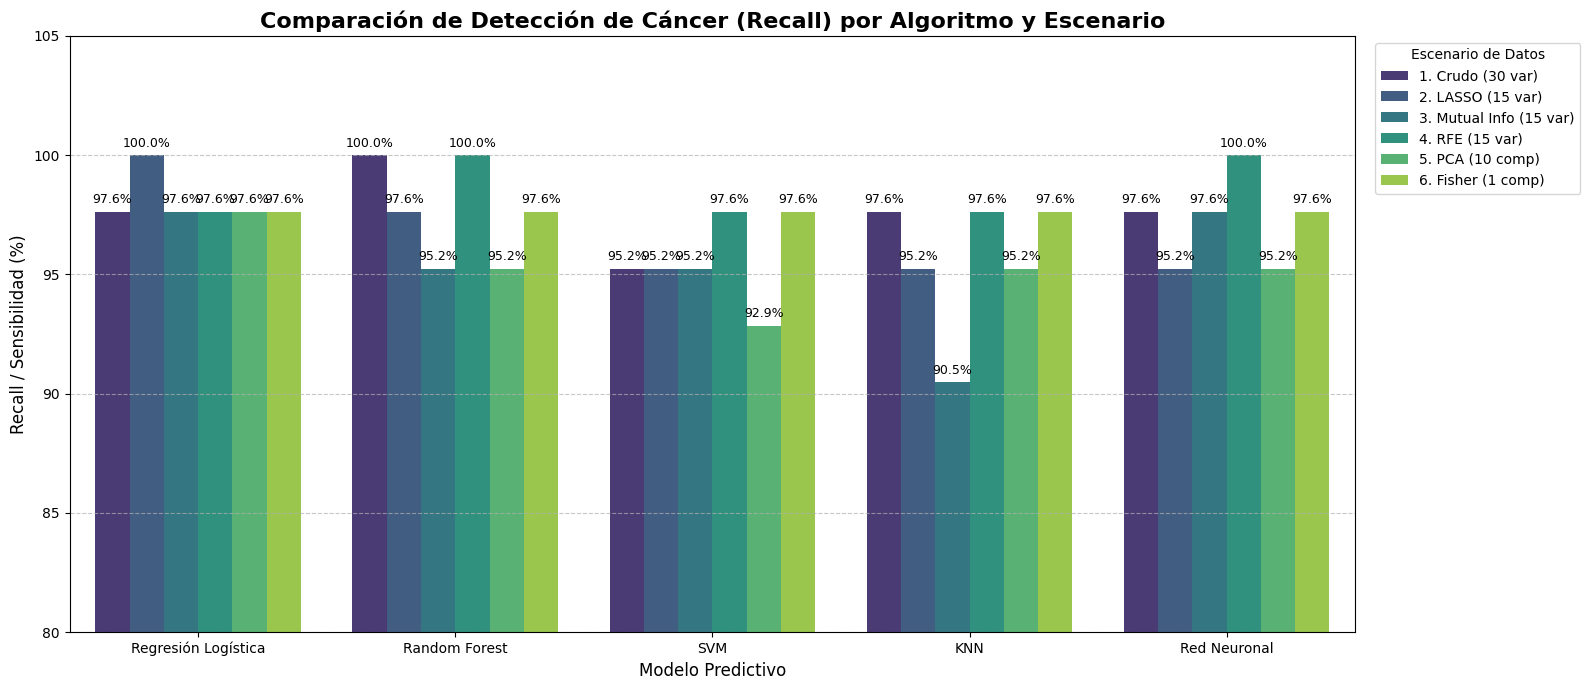

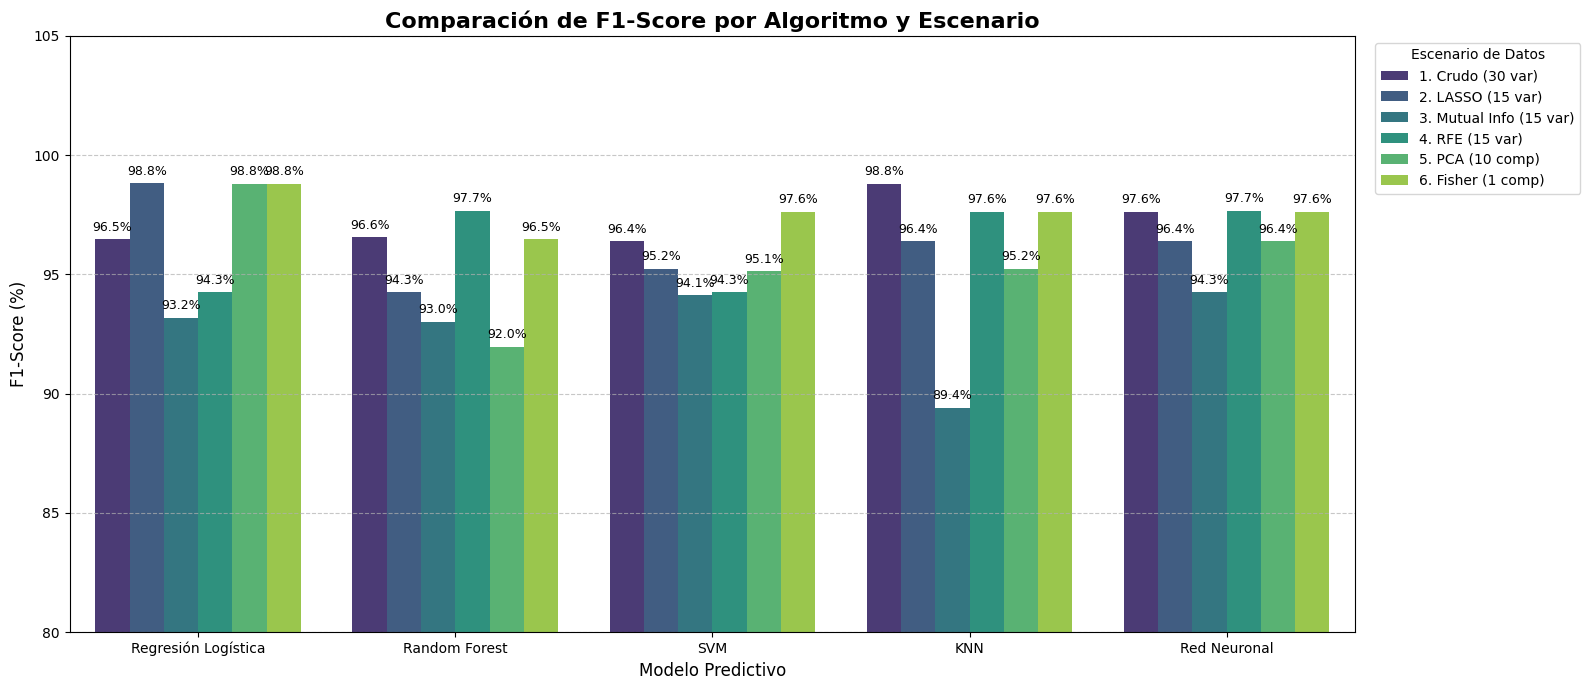

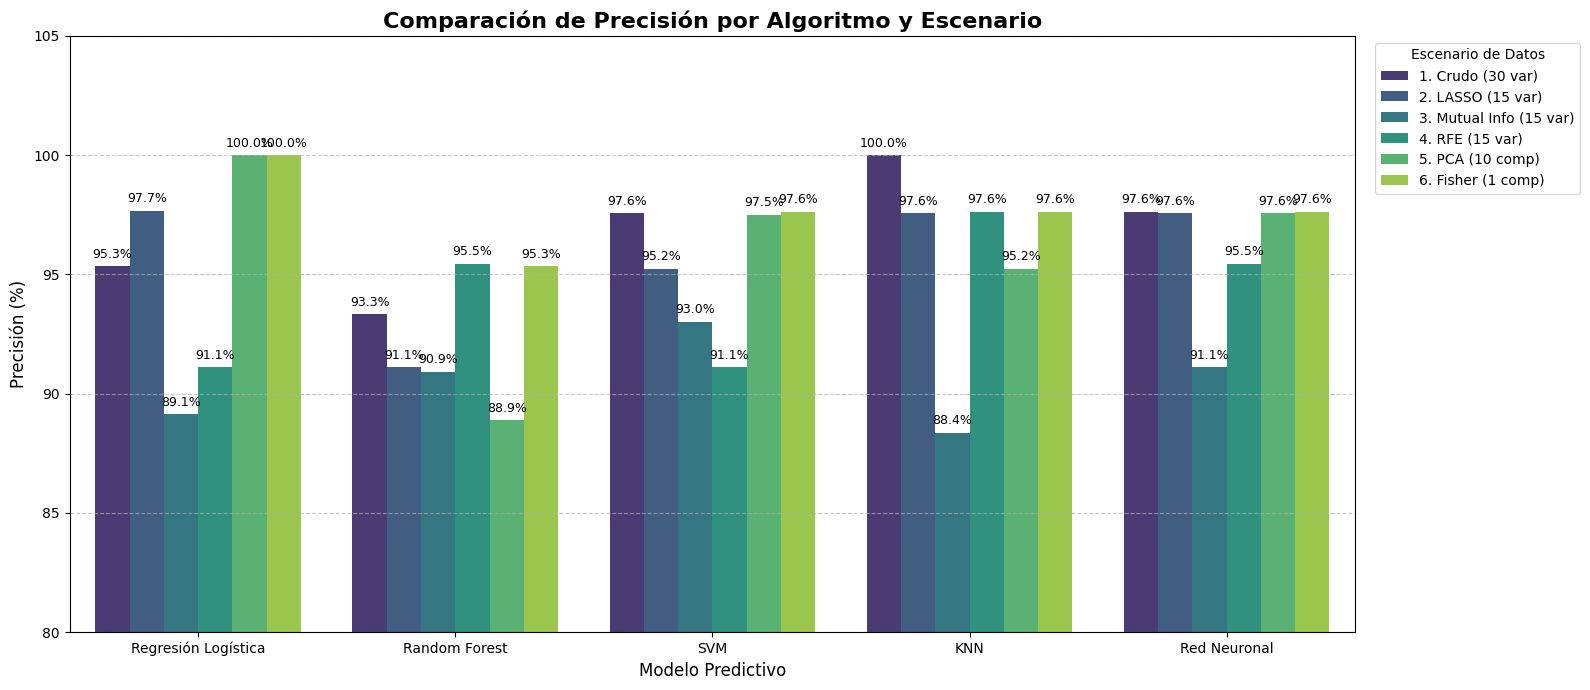

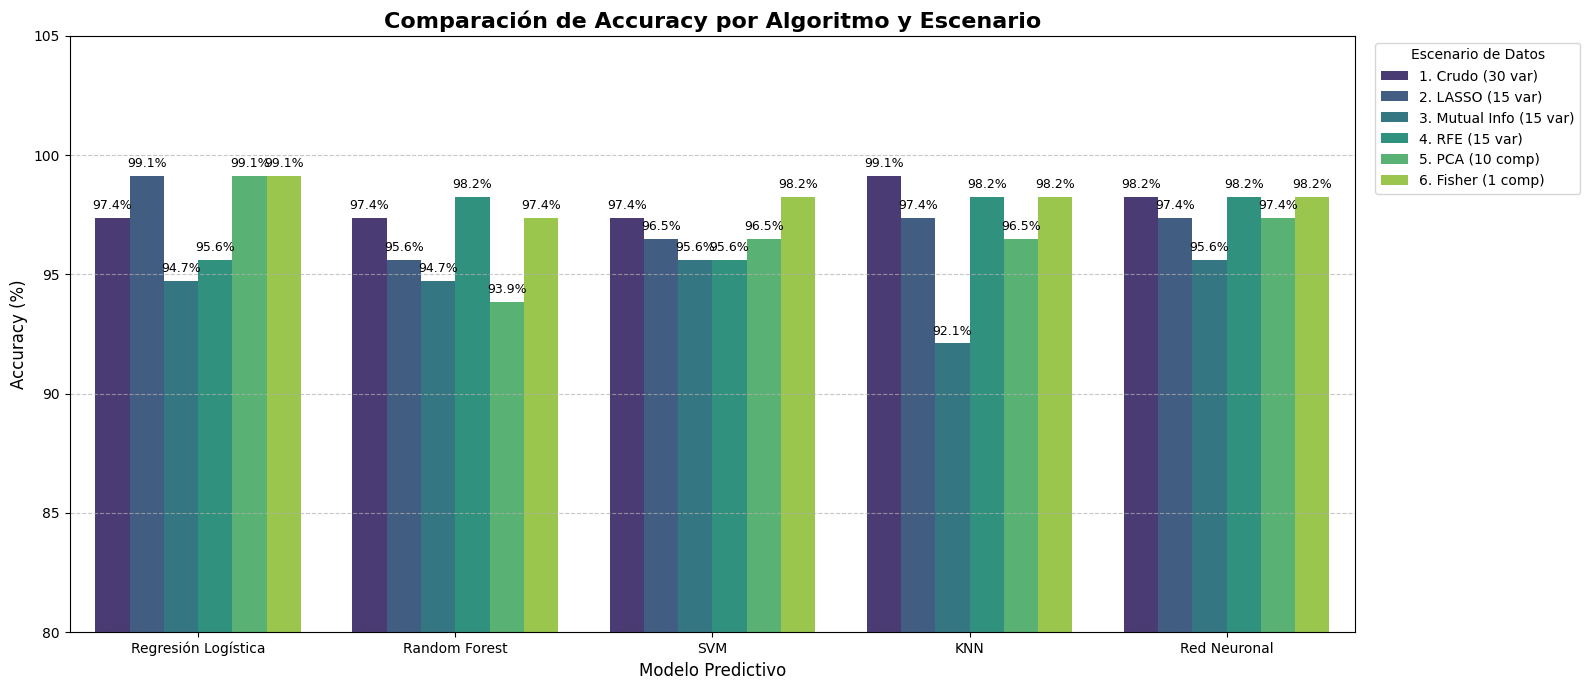

In [17]:
# Lista de métricas a graficar: (columna en el DataFrame, título del gráfico, etiqueta del eje Y)
metricas = [
    ('Recall TEST (Real)', 'Comparación de Detección de Cáncer (Recall) por Algoritmo y Escenario', 'Recall / Sensibilidad (%)'),
    ('F1-Score',           'Comparación de F1-Score por Algoritmo y Escenario',               'F1-Score (%)'),
    ('Precisión',          'Comparación de Precisión por Algoritmo y Escenario',              'Precisión (%)'),
    ('Accuracy',           'Comparación de Accuracy por Algoritmo y Escenario',               'Accuracy (%)')
]

for metrica, titulo, ylabel in metricas:
    plt.figure(figsize=(16, 7))
    
    grafico = sns.barplot(data=df_resultados_globales, x='Modelo', y=metrica, hue='Escenario', palette='viridis')
    
    # Ajustes estéticos respetando el formato del proyecto
    plt.ylim(80, 105)  # Margen superior para que quepan las etiquetas
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel('Modelo Predictivo', fontsize=12)
    
    # Mover la leyenda afuera para no tapar las barras
    plt.legend(title='Escenario de Datos', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Agregar los porcentajes exactos encima de cada barra
    for p in grafico.patches:
        if p.get_height() > 0:
            grafico.annotate(f"{p.get_height():.1f}%", 
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 4),
                               textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Conclusión Final

Tras un extenso Benchmarking de 5 arquitecturas predictivas sometidas a 6 escenarios de dimensionalidad (30 configuraciones en total), el criterio directriz para la validación del modelo ha sido la maximización del **Recall (Sensibilidad)**, un imperativo clínico para erradicar los Falsos Negativos en el diagnóstico de cáncer de mama.

**Hallazgos Clínico-Algorítmicos:**
1. Solo tres configuraciones lograron el objetivo clínico absoluto de **100% Recall** en la muestra de prueba: Regresión Logística (LASSO), Random Forest (RFE) y Red Neuronal (RFE).
2. Los modelos basados en distancia (KNN) y margen máximo (SVM) demostraron ser herramientas estadísticamente sólidas, pero insuficientes bajo la estricta penalización clínica de Falsos Negativos.
3. El uso del Discriminante de Fisher demostró ser la transformación más eficiente computacionalmente, maximizando la Exactitud general en 1D, pero perdiendo la varianza extrema necesaria para detectar el 100% de la clase maligna.

**Recomendación de Implementación:**
El modelo ganador definitivo es la **Regresión Logística impulsada por la selección incrustada LASSO**. 

* **Justificación Clínica:** Garantiza la detección del 100% de los casos malignos sin saturar el sistema de salud con biopsias innecesarias, al mantener un Accuracy del 99.12%.
* **Justificación Computacional:** Demostró un tiempo de ejecución extraordinariamente bajo (0.10s frente a los 5.07s de la Red Neuronal).
* **Justificación Médica (Caja Blanca):** A diferencia de Random Forest y MLP, la Regresión Logística mantiene una interpretabilidad total. El equipo de oncología puede extraer los coeficientes del modelo y auditar el peso exacto que variables como `concavity3` o `area3` tuvieron en la predicción final de un paciente específico.